In [152]:
import numpy as np
import matplotlib.pyplot as plt     

In [153]:
%%bash

g++ -std=c++17 -Wall Airfoil.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o myprogram

        

SRC/Flux.cpp: In member function ‘void Flux::compute_residual()’:
SRC/Flux.cpp:393:14: warning: unused variable ‘ghost_flag’ [-Wunused-variable]
  393 |         bool ghost_flag = false;
      |              ^~~~~~~~~~


In [154]:
%%bash
./myprogram

Shape = (2496, 4)
setting pointersSetting boundary types
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition


Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Found matching condition
Setting ambient Conditions...Setting inflow Conditions...Iteration: 0
Norms:
  Density   : 19.1958
  U-velocity: 5276.27
  V-velocity: 2.04337e-09
  Pressure  : 5.78464e+06
Iteration: 1
Norms:
  Density   : 18.9517
  U-velocity: 5202.96
  V-velocity: 201.013
  Pressure  : 5.69002e+06
Iteration: 2
Norms:
  Density   : 18.7002
  U-velocity: 5127.82
  V-velocity: 393.259
  Pressure  : 5.59511e+06
Iteration: 3
Norms:
  Density   : 18.442
  U-velocity: 5051.09
  V-velocity: 577.224
  Pressure  : 5.5001e+06
Iteration: 4
Norms:
  Density   : 18.1782
  U-velocity: 4972.99
  V-velocity: 753.33
  Pressure  : 5.40515e+06
Iteration: 5
Norms:
  Density   : 17.9095
  U-velocity: 4893.75
  V-velocity: 921.943
  Pressure  : 5.31044e+06
Iteration: 6
Norms:
  Density   : 17.6369
  U-velocity: 4813.58
  V-ve

In [155]:


data = np.loadtxt("primitives.csv", delimiter=",")
NI = 26
NJ = 96
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(4, 2496)


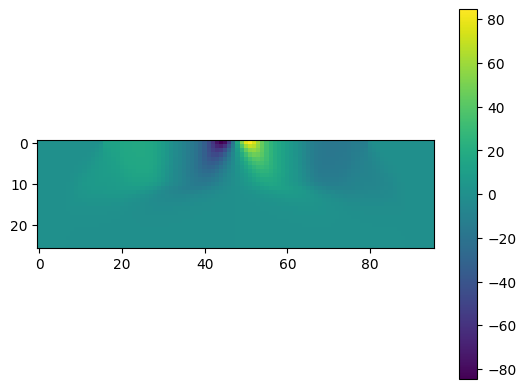

In [156]:
p = p.reshape((26,96))
plt.imshow(v)
plt.colorbar()

In [157]:
cell_L = np.array([np.median(rho),0,0,np.median(p)])
cell_R = np.array([np.max(rho),0,0,np.max(p)])

In [158]:
cell_R

array([9.15202e-01, 0.00000e+00, 0.00000e+00, 7.71091e+04])

In [159]:
# vanleer_flux_cell(cell_L,cell_R,1,0)

In [160]:
epsilon = 1e-10
gamma = 1.4
def vanleer_flux_cell(CELL_L,CELL_R,nx,ny):
    return f_convective_cell(CELL_L,CELL_R, nx,ny)+f_pressure_flux_cell(CELL_L,CELL_R, nx,ny)

def f_pressure_flux_cell(CELL_L,CELL_R,nx,ny):

    rho_L,rho_R = CELL_L[0],CELL_R[0]
    u_L,u_R = CELL_L[1],CELL_R[1]
    v_L,   v_R   = CELL_L[2], CELL_R[2]  # y-velocity
    p_L,   p_R   = CELL_L[3], CELL_R[3] 
    if np.any(rho_L<=0):
        rho_L = np.maximum(rho_L, epsilon)
    if np.any(rho_R<=0):
        rho_R = np.maximum(rho_R, epsilon)



    
    U_L = u_L*nx +ny*v_L
    U_R = u_R*nx+ny*v_R
    
    a_L = np.sqrt(np.maximum(epsilon,(gamma*(p_L/rho_L))))
    a_R = np.sqrt(np.maximum(epsilon,(gamma*(p_R/rho_R))))
    M_L,M_R = (U_L/a_L,U_R/a_R)
    
    alpha_plus = .5*(1+np.sign(M_L))
    alpha_minus = .5*(1-np.sign(M_R))
    beta_L = -np.maximum(0,1-np.floor(np.abs(M_L)))
    beta_R = -np.maximum(0,1-np.floor(np.abs(M_R)))

    M_plus = .25*(M_L+1)**2
    M_minus = -.25*(M_R-1)**2

    p_doubleBar_plus = M_plus*(-M_L+2)
    p_doubleBar_minus = M_minus*(-M_R-2)

    D_plus = alpha_plus*(1+beta_L)-beta_L*p_doubleBar_plus
    D_minus = alpha_minus*(1+beta_R)-beta_R*p_doubleBar_minus

    temp_zero = np.zeros_like(p_L)
    

    return np.array([temp_zero,nx*D_plus*p_L,ny*D_plus*p_L,temp_zero])+\
        np.array([temp_zero,nx*D_minus*p_R,ny*D_minus*p_R,temp_zero])

def c_plus_minus(alpha_plus_minus,beta_LR,mach_LR,M_plus_minus):
    return alpha_plus_minus*(1+beta_LR)*mach_LR-beta_LR*M_plus_minus


def f_convective_cell(CELL_L,CELL_R,nx,ny):
    rho_L,rho_R = CELL_L[0],CELL_R[0]
    u_L,u_R = CELL_L[1],CELL_R[1]
    v_L,   v_R   = CELL_L[2], CELL_R[2]  # y-velocity
    p_L,   p_R   = CELL_L[3], CELL_R[3] 
    if np.any(rho_L<=0):
        rho_L = np.maximum(rho_L, epsilon)
    if np.any(rho_R<=0):
        rho_R = np.maximum(rho_R, epsilon)
    
    U_L = u_L*nx +ny*v_L
    U_R = u_R*nx +ny*v_R



    a_L = np.sqrt(np.maximum(epsilon,(gamma*(p_L/rho_L))))
    a_R = np.sqrt(np.maximum(epsilon,(gamma*(p_R/rho_R))))
    M_L,M_R = (U_L/a_L,U_R/a_R)
    
    alpha_plus = .5*(1+np.sign(M_L))
    alpha_minus = .5*(1-np.sign(M_R))
    beta_L = -np.maximum(0,1-np.floor(np.abs(M_L)))
    beta_R = -np.maximum(0,1-np.floor(np.abs(M_R)))

    M_plus = .25*(M_L+1)**2
    M_minus = -.25*(M_R-1)**2

    
    ht_L = (gamma / (gamma - 1)) * (p_L / rho_L) + 0.5 * (u_L**2+v_L**2)
    ht_R = (gamma / (gamma - 1)) * (p_R / rho_R) + 0.5 * (u_R**2+v_R**2)

    temp_L = rho_L*a_L*c_plus_minus(alpha_plus,beta_L,M_L,M_plus)
    temp_R = rho_R*a_R*c_plus_minus(alpha_minus,beta_R,M_R,M_minus)
    FC_i_half = np.array([temp_L,u_L*temp_L,v_L*temp_L,ht_L*temp_L])+np.array([temp_R,u_R*temp_R,v_R*temp_R,ht_R*temp_R])

    return FC_i_half 

def prim_to_cons(W, gamma=1.4):
    """
    W: iterable of length 4 -> [rho, u, v, p]
    returns [rho, rho*u, rho*v, rho*E]
    """
    rho, u, v, p = W
    rho_u = rho * u
    rho_v = rho * v
    rho_E = p / (gamma - 1.0) + 0.5 * rho * (u*u + v*v)  # rho*e + kinetic
    return [rho, rho_u, rho_v, rho_E]


In [161]:
def load_grid(filename):

    with open(filename, 'r') as f:
        # Read integers
        nzones = int(f.readline())
        imax, jmax, kmax = map(int, f.readline().split())

        size = imax * jmax * kmax

        # Read the flattened data for x, y, and zztemp
        data = []
        while len(data) < 3 * size:
            line = f.readline()
            data.extend(map(float, line.split()))

        # Split data into x, y, zztemp
        data = np.array(data)
        x = data[0:size].reshape((kmax, jmax, imax))
        y = data[size:2*size].reshape((kmax, jmax, imax))
        zztemp = data[2*size:].reshape((kmax, jmax, imax))

    return x[0],y[0]
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.coarse.53x27.grd")

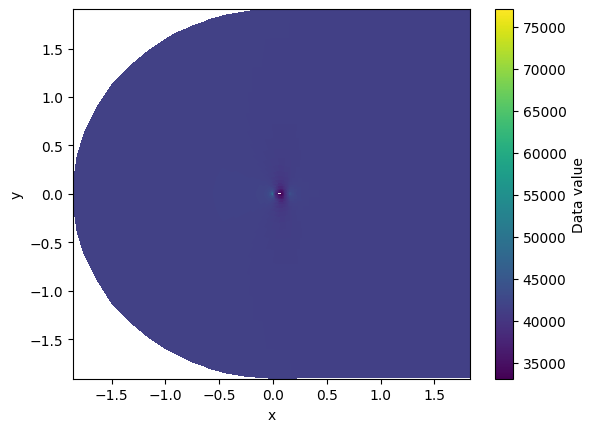

In [162]:
 

plt.pcolormesh(x[:,:], y[:,:], p[:,:], shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [163]:
import pyvista as pv

midpoint_tempx = (x[1:,:]+x[0:-1,:])/2
midpointxx = (midpoint_tempx[:,1:]+midpoint_tempx[:,0:-1])/2
midpoint_tempy = (y[1:,:]+y[0:-1,:])/2
midpointyy = (midpoint_tempy[:,1:]+midpoint_tempy[:,0:-1])/2



xx = midpointxx
grid = pv.StructuredGrid(midpointxx,midpointyy, np.zeros_like(p))

grid["pressure"] = p.T.flatten()
Ux =u.T
Uy = v.T
vel = np.stack([Ux, Uy, np.zeros_like(Ux)], axis=-1).reshape(-1, 3)
grid["velocity"] = vel
grid.save("Airfoil.vtk")  # or .vtu

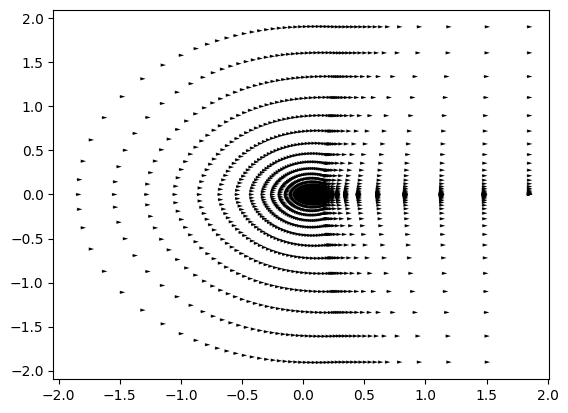

In [164]:
plt.quiver(x[1:,1:],y[1:,1:],u,v)